<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 5: Regresión Logística para reviews de Películas</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad se abordará la implementación de un modelo de análisis de sentimientos para peliculas.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Considere el review de peliculas del archivo "moviereviews.tsv" que se encuentr en la carpeta Data</li>
<li>Cree un modelo de Regresión Logística para clasificación de sentimientos con las funciones vistas en clase.</li>

</ul>
</div>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from utils import process_tweet

import nltk
from nltk.corpus import stopwords

In [27]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [22]:
#Clase Regresión Logística Sentimiento (vista en clase)
class RegresionLogisticaSentimiento:
    """Regresion logistica binaria con gradiente descendente batch."""

    def __init__(self, lr=0.1, epochs=500, lambda_=0.01, umbral=0.5):
        self.lr = lr; self.epochs = epochs
        self.lambda_ = lambda_; self.umbral = umbral
        self.w = None; self.b = 0.0; self.historial = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _perdida(self, y_hat, y):
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        ce = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return ce + (self.lambda_ / 2) * np.dot(self.w, self.w)

    def fit(self, X, y, verbose=True):
        N, D = X.shape
        self.w = np.zeros(D); self.b = 0.0; self.historial = []
        for epoch in range(self.epochs):
            y_hat = self._sigmoid(X.dot(self.w) + self.b)
            loss = self._perdida(y_hat, y)
            self.historial.append(loss)
            error = y_hat - y
            grad_w = X.T.dot(error) / N + self.lambda_ * self.w
            grad_b = np.mean(error)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            if verbose and (epoch % 100 == 0 or epoch == self.epochs - 1):
                acc = accuracy_score(y, self.predecir(X))
                print(f"  Epoch {epoch:4d} | Perdida: {loss:.4f} | Acc train: {acc:.4f}")
        return self

    def predecir_proba(self, X):
        return self._sigmoid(X.dot(self.w) + self.b)

    def predecir(self, X):
        return (self.predecir_proba(X) >= self.umbral).astype(int)

    def palabras_importantes(self, vocab, top_n=10):
        idx_pos = np.argsort(self.w)[::-1][:top_n]
        idx_neg = np.argsort(self.w)[:top_n]
        return [(vocab[i], self.w[i]) for i in idx_pos], [(vocab[i], self.w[i]) for i in idx_neg]

print("Clase RegresionLogisticaSentimiento lista.")

Clase RegresionLogisticaSentimiento lista.


### Descripción y detalles de Dataset: moviereviews.tsv

In [76]:
# Extraemos el review de peliculas del archivo "moviereviews.tsv"

df = pd.read_csv('/content/sample_data/moviereviews.tsv', sep='\t')
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [77]:
#Identificamos si existen líneas vacías o en blanco
print("IDENTIFICACIÓN DE LÍNEAS VACÍAS")
print("=" * 55)
print(df.isna().sum())

IDENTIFICACIÓN DE LÍNEAS VACÍAS
label      0
review    35
dtype: int64


In [78]:
print("REEMPLAZO Y ELIMINACIÓN DE REVIEW VACÍAS")
print("=" * 55)
df.dropna(inplace=True)
print(df.isna().sum())

REEMPLAZO Y ELIMINACIÓN DE REVIEW VACÍAS
label     0
review    0
dtype: int64


In [79]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [91]:
# Procesamiento de Texto
# Uso de la función "process_tweet" de la librería "utils" que se proporciono en clases
# Tokeniza el tweet en palabras individuales, elimina los stopwords, aplica steammer, normalizacion y tokenización

def preprocesar_texto(texto):
    lista_palabras = process_tweet(texto)
    return " ".join(lista_palabras)

# process_tweet devuelve una lista, la unimos en un string
df['review_limpio'] = df['review'].apply(preprocesar_texto)
df.head(3)

,label,review,review_limpio
0,0,how do films like mouse hunt get into theatres...,film like mous hunt get theatr law someth diab...
1,0,some talented actresses are blessed with a dem...,talent actress bless demonstr wide act rang ot...
2,1,this has been an extraordinary year for austra...,extraordinari year australian film shine scoop...


In [83]:
# Hacemos la conversión de las etiquetas de texto a númerico,
# Datos binarios (pos = 1, neg = 0)

if df['label'].dtype == 'object':
    df['label'] = df['label'].map({'pos': 1, 'neg': 0})
    df['label'] = df['label'].astype(int)

In [86]:
# Arreglo
X_bin = (df['review_limpio']).values
y_bin = (df['label']).values

In [89]:
# Declaramos entrenamiento y prueba
X_tr, X_te, y_tr, y_te = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
print(f"Train: {len(X_tr)}  Test: {len(X_te)}")


Train: 1572  Test: 393


In [92]:
# Vectorizacion TF-IDF
tfidf_lr = TfidfVectorizer(max_features=1200, min_df=3, max_df=0.8)

# Convirtiendo los textos a matrices numéricas se agrega astype('float32') para aligerar
X_train = tfidf_lr.fit_transform(X_tr).toarray().astype('float32')
X_test = tfidf_lr.transform(X_te).toarray().astype('float32')

# Vocabulario de las palabras más importantes
vocab_lr = tfidf_lr.get_feature_names_out()

In [98]:
# Instanciar y Entrenamiento del modelo Regresión Logística (rl)
# Usando la Class RegresionLogisticaSentimiento

print()
print("Entrenando Regresión Logística desde cero...")
print("=" * 55)
rl = RegresionLogisticaSentimiento(lr=0.3, epochs=2000, lambda_=0.01, umbral=0.5)
rl.fit(X_train, y_tr, verbose=True)
print("Entrenamiento Completo")

# También se entreno con estos parametros, pero el final fue con mejor resultados
# rl = RegresionLogisticaSentimiento(lr=0.3, epochs=500, lambda_=0.01, umbral=0.5)
# rl = RegresionLogisticaSentimiento(lr=0.1, epochs=800, lambda_=0.01, umbral=0.5)


Entrenando Regresión Logística desde cero...
  Epoch    0 | Perdida: 0.6931 | Acc train: 0.8492
  Epoch  100 | Perdida: 0.6782 | Acc train: 0.8581
  Epoch  200 | Perdida: 0.6706 | Acc train: 0.8594
  Epoch  300 | Perdida: 0.6667 | Acc train: 0.8601
  Epoch  400 | Perdida: 0.6647 | Acc train: 0.8607
  Epoch  500 | Perdida: 0.6637 | Acc train: 0.8613
  Epoch  600 | Perdida: 0.6632 | Acc train: 0.8613
  Epoch  700 | Perdida: 0.6629 | Acc train: 0.8626
  Epoch  800 | Perdida: 0.6628 | Acc train: 0.8639
  Epoch  900 | Perdida: 0.6627 | Acc train: 0.8639
  Epoch 1000 | Perdida: 0.6627 | Acc train: 0.8645
  Epoch 1100 | Perdida: 0.6627 | Acc train: 0.8645
  Epoch 1200 | Perdida: 0.6627 | Acc train: 0.8645
  Epoch 1300 | Perdida: 0.6627 | Acc train: 0.8651
  Epoch 1400 | Perdida: 0.6627 | Acc train: 0.8651
  Epoch 1500 | Perdida: 0.6627 | Acc train: 0.8658
  Epoch 1600 | Perdida: 0.6627 | Acc train: 0.8658
  Epoch 1700 | Perdida: 0.6627 | Acc train: 0.8658
  Epoch 1800 | Perdida: 0.6627 | Acc

REPORTE EN CONJUNTO DE PRUEBA
              precision    recall  f1-score   support

    negativo       0.78      0.78      0.78       197
    positivo       0.78      0.78      0.78       196

    accuracy                           0.78       393
   macro avg       0.78      0.78      0.78       393
weighted avg       0.78      0.78      0.78       393



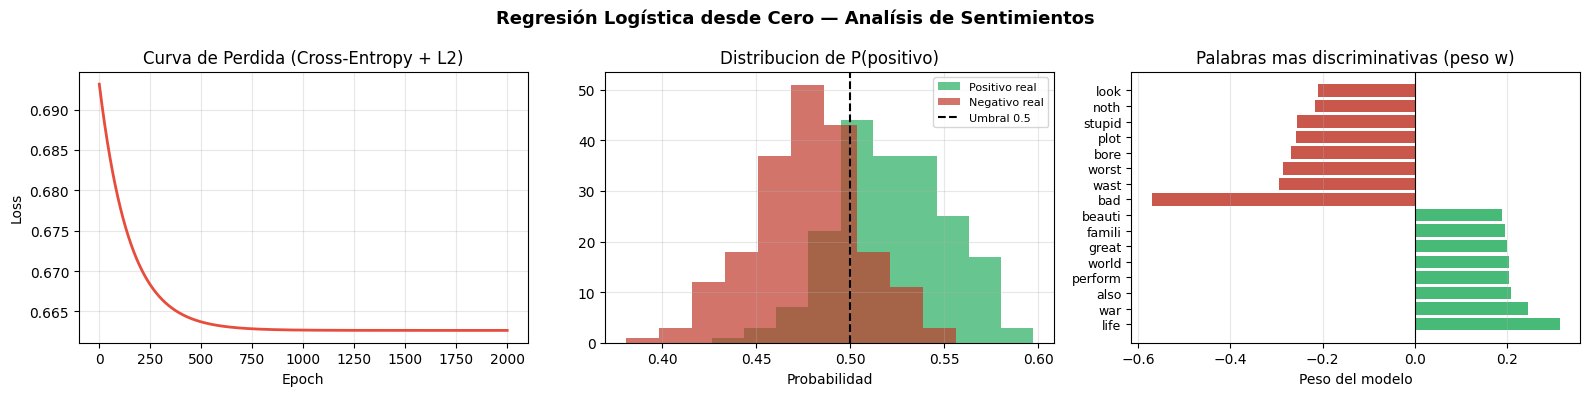

In [99]:
# Evaluacion del Modelo rl
# Uso de las funciones predecir(), predecir_proba(), palabras_importantes()
# de la Class RegresionLogisticaSentimiento

y_pred_bin  = rl.predecir(X_test)
y_proba_bin  = rl.predecir_proba(X_test)

print("REPORTE EN CONJUNTO DE PRUEBA")
print("=" * 55)
print(classification_report(y_te, y_pred_bin, target_names=['negativo', 'positivo']))

# Visualizacion: 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Regresión Logística desde Cero — Analísis de Sentimientos',
             fontsize=13, fontweight='bold')

# 1. Curva de perdida
axes[0].plot(rl.historial, color='#e74c3c', linewidth=2)
axes[0].set_title('Curva de Perdida (Cross-Entropy + L2)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

# 2. Distribucion de probabilidades
axes[1].hist(y_proba_bin[y_te == 1], bins=10, alpha=0.7, color='#27ae60', label='Positivo real')
axes[1].hist(y_proba_bin[y_te == 0], bins=10, alpha=0.7, color='#c0392b', label='Negativo real')
axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
axes[1].set_title('Distribucion de P(positivo)')
axes[1].set_xlabel('Probabilidad'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# 3. Palabras mas discriminativas
positivas, negativas = rl.palabras_importantes(vocab_lr, top_n=8)
all_words   = [w for w, _ in positivas] + [w for w, _ in negativas]
all_weights = [s for _, s in positivas] + [s for _, s in negativas]
colors_bar  = ['#27ae60'] * len(positivas) + ['#c0392b'] * len(negativas)
axes[2].barh(range(len(all_words)), all_weights, color=colors_bar, alpha=0.85)
axes[2].set_yticks(range(len(all_words)))
axes[2].set_yticklabels(all_words, fontsize=9)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Palabras mas discriminativas (peso w)')
axes[2].set_xlabel('Peso del modelo'); axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()